In [1]:
pip install opencv-python numpy


**Load and Display an Image**

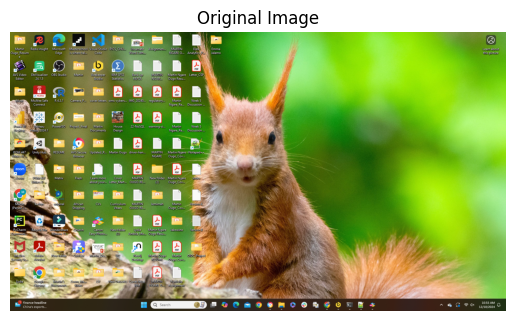

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Load the image
image = cv2.imread('Pic.png')  # Replace with your actual image file

# Check if the image was loaded successfully
if image is None:
    print("Error: Could not load image. Please check the file path.")
else:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB format

    # Display the image
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis("off")
    plt.show()

**Rotate the Image**

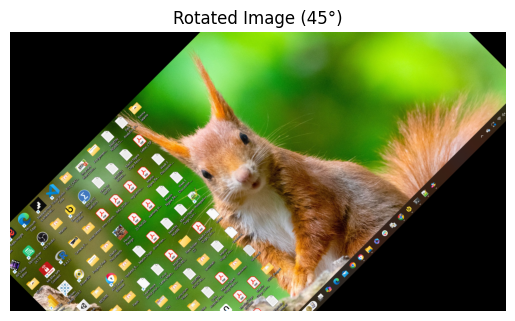

In [16]:
# Define rotation parameters
(h, w) = image.shape[:2]  # Get image height and width
center = (w // 2, h // 2)  # Find the center of the image
angle = 45  # Rotate by 45 degrees
scale = 1.0  # Keep the scale the same

# Create the rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(center, angle, scale)

# Apply the rotation
rotated_image = cv2.warpAffine(image, rotation_matrix, (w, h))

# Display the rotated image
plt.imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
plt.title("Rotated Image (45°)")
plt.axis("off")
plt.show()

**Scale the Image**

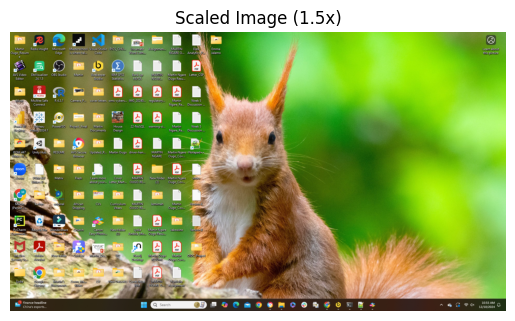

In [17]:
# Scale the image by 1.5x
scaled_image = cv2.resize(image, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

# Display the scaled image
plt.imshow(cv2.cvtColor(scaled_image, cv2.COLOR_BGR2RGB))
plt.title("Scaled Image (1.5x)")
plt.axis("off")
plt.show()

**Simulate Different Camera Parameters**

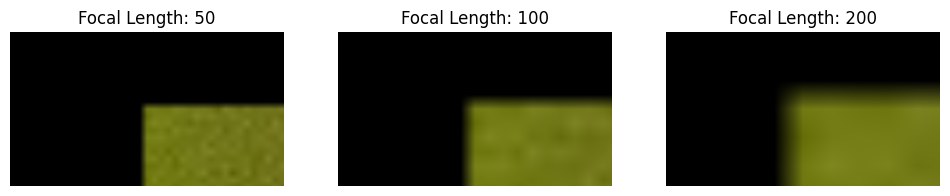

In [19]:
# Define focal length variations
focal_lengths = [50, 100, 200]

# Display different focal lengths
plt.figure(figsize=(12, 4))
if image is None:
    print("Error: Could not load image. Please check the file path.")
else:
    (h, w) = image.shape[:2]  # Get image height and width
    for i, f in enumerate(focal_lengths):
        # Camera intrinsic matrix - ensure it's a floating-point type
        f_matrix = np.array([[f, 0, w//2], [0, f, h//2], [0, 0, 1]], dtype=np.float32)
        warped_image = cv2.warpPerspective(image, f_matrix, (w, h))

        plt.subplot(1, 3, i+1)
        plt.imshow(cv2.cvtColor(warped_image, cv2.COLOR_BGR2RGB))
        plt.title(f"Focal Length: {f}")
        plt.axis("off")

    plt.show()

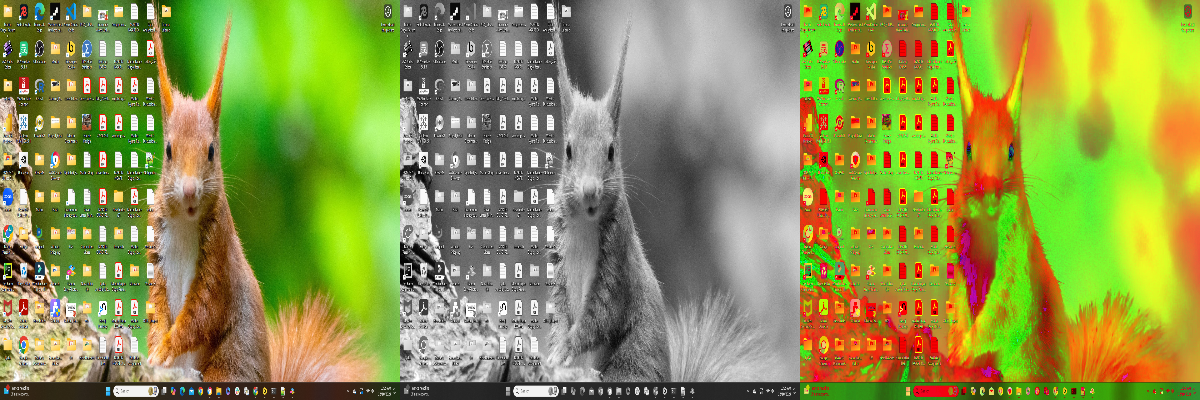

False

In [21]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load original image
img = cv2.imread('Pic.png')

# Convert to Grayscale and HSV
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Convert single-channel grayscale to 3-channel for visualization
gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Stack images horizontally
comparison = np.hstack((img, gray_3ch, hsv))

# Resize for better display if needed
comparison = cv2.resize(comparison, (1200, 400))

# Display
cv2_imshow(comparison)
# cv2.waitKey(0) # waitKey is not needed with cv2_imshow
# cv2.destroyAllWindows() # destroyAllWindows is not needed with cv2_imshow

# Save for presentation
cv2.imwrite('results/grayscale_hsv_comparison.jpg', comparison)

In [25]:
import cv2
import numpy as np
import os

# Create results folder if it doesn't exist
os.makedirs('results', exist_ok=True)

# Load original image
img = cv2.imread('Pic.png')
(h, w) = img.shape[:2]

# --- 1. Grayscale / HSV ---
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
gray_3ch = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
grayscale_hsv = np.hstack((img, gray_3ch, hsv))
grayscale_hsv = cv2.resize(grayscale_hsv, (1200, 400))
cv2.imwrite('results/grayscale_hsv_comparison.jpg', grayscale_hsv)

# --- 2. Scaling ---
scaled = cv2.resize(img, None, fx=0.5, fy=0.5)
scaled_upsized = cv2.resize(scaled, (w, h))  # resize back for comparison
scaling_comparison = np.hstack((img, scaled_upsized))
cv2.imwrite('results/scaling_comparison.jpg', scaling_comparison)

# --- 3. Rotation ---
M_rot = cv2.getRotationMatrix2D((w/2, h/2), 45, 1)
rotated = cv2.warpAffine(img, M_rot, (w, h))
rotation_comparison = np.hstack((img, rotated))
cv2.imwrite('results/rotation_comparison.jpg', rotation_comparison)

# --- 4. Translation ---
M_trans = np.float32([[1, 0, 50], [0, 1, 100]])
translated = cv2.warpAffine(img, M_trans, (w, h))
translation_comparison = np.hstack((img, translated))
cv2.imwrite('results/translation_comparison.jpg', translation_comparison)

# --- 5. Blending ---
blend = cv2.addWeighted(img, 0.7, rotated, 0.3, 0)
blending_comparison = np.hstack((img, blend))
cv2.imwrite('results/blending_comparison.jpg', blending_comparison)

print("All comparison images saved in 'results/' folder.")

All comparison images saved in 'results/' folder.


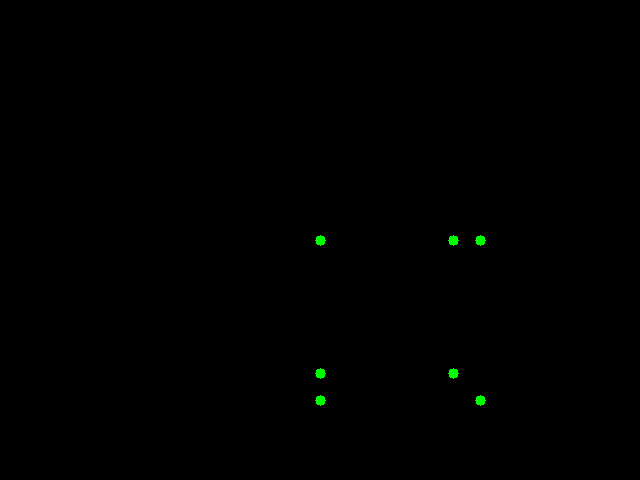

True

In [27]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Define simple 3D points (cube corners)
points_3d = np.array([
    [0, 0, 5],
    [1, 0, 5],
    [1, 1, 5],
    [0, 1, 5],
    [0, 0, 6],
    [1, 0, 6],
    [1, 1, 6],
    [0, 1, 6]
], dtype=np.float32)

# Camera intrinsic parameters
focal_length = 800  # pixels
image_width = 640
image_height = 480
K = np.array([
    [focal_length, 0, image_width / 2],
    [0, focal_length, image_height / 2],
    [0, 0, 1]
])

# Project 3D points to 2D using pinhole model
projected_points = []
for X, Y, Z in points_3d:
    x = (focal_length * X) / Z + image_width / 2
    y = (focal_length * Y) / Z + image_height / 2
    projected_points.append((int(x), int(y)))

projected_points = np.array(projected_points)

# Draw on blank image
img = np.zeros((image_height, image_width, 3), dtype=np.uint8)
for point in projected_points:
    cv2.circle(img, point, 5, (0, 255, 0), -1)

cv2_imshow(img)
cv2.imwrite("results/pinhole_projection.jpg", img)
# cv2.waitKey(0) # waitKey is not needed with cv2_imshow
# cv2.destroyAllWindows() # destroyAllWindows is not needed with cv2_imshow